In [ ]:
import os
import re
import string
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
df = pd.read_csv("cleaned_flipkart_reviews.csv")

df.head()

,Product_name,Review,Rating,Sentiment,Review_Length,Clean_Review
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,Positive,324,best k great performancei got around battery b...
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,Positive,18,good perfomence
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,Positive,215,great performance usually also gaming laptop i...
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,Positive,40,wife happy best product 👌🏻😘
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,Positive,71,light weight laptop new amazing feature batter...


In [ ]:
print(df["Sentiment"].value_counts())

if "Rating" in df.columns:
    expected = df["Rating"].apply(
        lambda r: "Positive" if r >= 4 else ("Neutral" if r == 3 else "Negative")
    )
    mismatch = (expected != df["Sentiment"]).sum()
    print("Rating -> Sentiment mismatches:", mismatch)

Sentiment
Positive    1857
Negative     206
Neutral      118
Name: count, dtype: int64
Rating -> Sentiment mismatches: 0


In [ ]:
lemmatizer = WordNetLemmatizer()

# Keep negation words so meaning-critical terms are not stripped out
stop_words = set(stopwords.words("english"))
stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("nor")

In [ ]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = word_tokenize(text)

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
# Sanity check: negation words must be preserved
assert clean_text("not good") == "not good", clean_text("not good")
assert clean_text("not worth buying") == "not worth buying", clean_text("not worth buying")

print(clean_text("not good"))
print(clean_text("Waste of money"))
print(clean_text("Worst phone ever"))
print(clean_text("Battery is very poor"))

not good
waste money
worst phone ever
battery poor


In [ ]:
df["Clean_Review"] = df["Review"].apply(clean_text)

df.head()

,Product_name,Review,Rating,Sentiment,Review_Length,Clean_Review
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,Positive,324,best k great performancei got around battery b...
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,Positive,18,good perfomence
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,Positive,215,great performance usually also gaming laptop i...
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,Positive,40,wife happy best product 👌🏻😘
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,Positive,71,light weight laptop new amazing feature batter...


In [ ]:
X = df["Clean_Review"]
y = df["Sentiment"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2
)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, pred))
print()
print(classification_report(y_test, pred))

Accuracy: 0.9221967963386728

              precision    recall  f1-score   support

    Negative       0.97      0.88      0.92        41
     Neutral       0.45      0.92      0.60        24
    Positive       0.98      0.93      0.95       372

    accuracy                           0.92       437
   macro avg       0.80      0.91      0.83       437
weighted avg       0.95      0.92      0.93       437



[[ 36   1   4]
 [  0  22   2]
 [  1  26 345]]


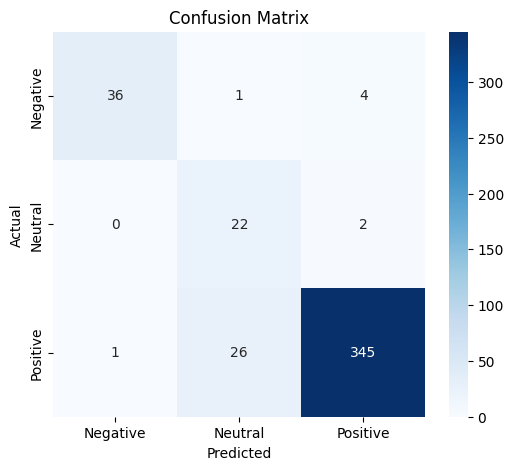

In [ ]:
cm = confusion_matrix(y_test, pred, labels=model.classes_)

print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

Cross-Validation Accuracy Scores: [0.88538682 0.89684814 0.92836676 0.91117479 0.90229885]
Mean CV Accuracy: 0.9048150709745414
Std CV Accuracy: 0.014438756676222256


In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

svm = LinearSVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred),
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_svm),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred, average="weighted"),
        precision_score(y_test, pred_nb, average="weighted"),
        precision_score(y_test, pred_svm, average="weighted"),
        precision_score(y_test, pred_rf, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, pred, average="weighted"),
        recall_score(y_test, pred_nb, average="weighted"),
        recall_score(y_test, pred_svm, average="weighted"),
        recall_score(y_test, pred_rf, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, pred, average="weighted"),
        f1_score(y_test, pred_nb, average="weighted"),
        f1_score(y_test, pred_svm, average="weighted"),
        f1_score(y_test, pred_rf, average="weighted")
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.947368,0.946122,0.947368,0.944375
2,Linear SVM,0.947368,0.945250,0.947368,0.943006
0,Logistic Regression,0.922197,0.952651,0.922197,0.932111
1,Naive Bayes,0.862700,0.826850,0.862700,0.808128


In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())

print("Top 20 Positive Words:")
pos_idx = list(model.classes_).index("Positive")
top_pos = np.argsort(model.coef_[pos_idx])[-20:][::-1]
for word, coef in zip(feature_names[top_pos], model.coef_[pos_idx][top_pos]):
    print(f"{word}: {coef:.4f}")

print()
print("Top 20 Negative Words:")
neg_idx = list(model.classes_).index("Negative")
top_neg = np.argsort(model.coef_[neg_idx])[-20:][::-1]
for word, coef in zip(feature_names[top_neg], model.coef_[neg_idx][top_neg]):
    print(f"{word}: {coef:.4f}")

Top 20 Positive Words:
best: 1.8722
great: 1.5780
awesome: 1.4346
happy: 1.3083
not bad: 1.1944
also: 1.1546
superb: 1.0616
excellent: 1.0459
really: 1.0447
delivery: 0.9873
thanks: 0.9728
thank: 0.9722
nice phone: 0.9398
amazing: 0.9060
super: 0.8586
nice: 0.8311
good: 0.7752
speaker: 0.7374
monitor: 0.7349
price: 0.7075

Top 20 Negative Words:
not: 2.4438
bad: 2.2934
dont: 2.2057
waste: 2.0590
worst: 1.8920
poor: 1.8018
not good: 1.6416
dont buy: 1.5423
problem: 1.4713
hanging: 1.2355
loss: 1.1766
drain fast: 1.1473
slow: 1.1149
heavy noise: 1.0474
loss money: 1.0278
poor quality: 1.0140
phone slow: 1.0023
getting: 0.9578
heavy: 0.9513
totally: 0.9332


In [ ]:
reviews = [
    "Excellent product",
    "Worst phone ever",
    "Waste of money",
    "Battery is very poor",
    "Camera is bad",
    "not good",
    "not worth buying",
    "Terrible experience"
]

cleaned_reviews = [clean_text(r) for r in reviews]
X_custom = vectorizer.transform(cleaned_reviews)

predictions = model.predict(X_custom)
probabilities = model.predict_proba(X_custom)

for review, pred_label, prob in zip(reviews, predictions, probabilities):
    print("-" * 60)
    print("Review     :", review)
    print("Prediction :", pred_label)
    print("Confidence :", round(max(prob) * 100, 2), "%")

------------------------------------------------------------
Review     : Excellent product
Prediction : Positive
Confidence : 81.64 %
------------------------------------------------------------
Review     : Worst phone ever
Prediction : Negative
Confidence : 86.17 %
------------------------------------------------------------
Review     : Waste of money
Prediction : Negative
Confidence : 83.17 %
------------------------------------------------------------
Review     : Battery is very poor
Prediction : Negative
Confidence : 79.28 %
------------------------------------------------------------
Review     : Camera is bad
Prediction : Negative
Confidence : 83.23 %
------------------------------------------------------------
Review     : not good
Prediction : Negative
Confidence : 74.94 %
------------------------------------------------------------
Review     : not worth buying
Prediction : Negative
Confidence : 48.53 %
------------------------------------------------------------
Review   

In [ ]:
model_path = "sentiment_model.pkl"
vectorizer_path = "tfidf_vectorizer.pkl"

joblib.dump(model, model_path)
joblib.dump(vectorizer, vectorizer_path)

print("Model saved at:", os.path.abspath(model_path), "| exists:", os.path.exists(model_path))
print("Vectorizer saved at:", os.path.abspath(vectorizer_path), "| exists:", os.path.exists(vectorizer_path))

Model saved at: /content/sentiment_model.pkl | exists: True
Vectorizer saved at: /content/tfidf_vectorizer.pkl | exists: True
